# 👉 Features : 
#     1. Expense Input and Validation (Control Structure & Arrays - Low Weightage)
#        • Accept user input for expenses, including the date, amount, category, and description.
#        • Validate inputs using control structures (e.g., ensure the amount is positive and the category is valid).


In [7]:
# List of valid expense categories
valid_categories = ["Food", "Transport", "Rent", "Entertainment", "Utilities"]

def get_expense_input():
    print("--- Enter New Expense ---")
    print("                         ")
    # 1. Date Input
    date = input("Enter the date (YYYY-MM-DD): ")
    
    # 2. Amount Input with Validation
    while True:
        try:
            amount = float(input("Enter the amount: "))
            if amount > 0:
                break
            else:
                print("Error: Amount must be a positive number.")
        except ValueError:
            print("Error: Please enter a valid numerical value for the amount.")

    # 3. Category Input with Validation
    while True:
        print(f"Valid Categories: {', '.join(valid_categories)}")
        category = input("Enter the category: ").capitalize()
        if category in valid_categories:
            break
        else:
            print(f"Error: '{category}' is not a valid category. Please try again.")

    # 4. Description Input
    description = input("Enter a brief description: ")

    # Store data in a dictionary (or list)
    expense_data = {
        "date": date,
        "amount": amount,
        "category": category,
        "description": description
    }
    
    print("\nExpense logged successfully!")
    return expense_data

expense = get_expense_input()
print(expense)


--- Enter New Expense ---
                         


Enter the date (YYYY-MM-DD):  2026-07-14
Enter the amount:  -30


Error: Amount must be a positive number.


Enter the amount:  120.58


Valid Categories: Food, Transport, Rent, Entertainment, Utilities


Enter the category:  Luxury


Error: 'Luxury' is not a valid category. Please try again.
Valid Categories: Food, Transport, Rent, Entertainment, Utilities


Enter the category:  Food
Enter a brief description:  Dinner with friends



Expense logged successfully!
{'date': '2026-07-14', 'amount': 120.58, 'category': 'Food', 'description': 'Dinner with friends'}


# 2. Expense Tracker Class (OOP-Medium Weightage)
#    • Design an Expense Tracker class with the following methods:
#       ° add_expense(self, date, amount, category, description): Logs new expenses into the dataset.
#       ° get_summary(self): Provides a summary of total and average expenses.
#       ° ilter_expenses(self, condition): Filters expenses by category, date range, or amount
#       ° generate_report(self): Outputs a summary report with key metrics.

In [2]:
class ExpenseTracker:
    def __init__(self):
        self.expenses = []

    def add_expense(self, date, amount, category, description):
        """Logs new expenses into the dataset."""
        expense = {
            "date": date,
            "amount": amount,
            "category": category,
            "description": description
        }
        self.expenses.append(expense)
        print(f"Added: {description} (₹{amount})")

    def get_summary(self):
        """Provides a summary of total and average expenses."""
        if not self.expenses:
            return 0, 0
        
        total = sum(exp['amount'] for exp in self.expenses)
        average = total / len(self.expenses)
        return total, average

    def filter_expenses(self, key, value):
        """Filters expenses by a specific field and value (e.g., category or date)."""
        filtered = [exp for exp in self.expenses if exp.get(key) == value]
        return filtered

    def generate_report(self):
        """Outputs a summary report with key metrics."""
        total, average = self.get_summary()
        print("\n--- Expense Report ---")
        print(f"Total Transactions: {len(self.expenses)}")
        print(f"Total Spent:        ₹{total:.2f}")
        print(f"Average Expense:    ₹{average:.2f}")
        print("----------------------\n")

tracker = ExpenseTracker()

# 1. Adding Expenses
tracker.add_expense("2026-07-01", 70.0, "Food", "Grocery shopping")
tracker.add_expense("2026-07-02", 30.0, "Transport", "Bus fare")
tracker.add_expense("2026-07-03", 140.0, "Food", "Dinner out")

# 2. Generating Report
tracker.generate_report()

# 3. Filtering Expenses (e.g., by category 'Food')
food_expenses = tracker.filter_expenses("category", "Food")
print(f"Found {len(food_expenses)} items in 'Food' category.")


Added: Grocery shopping (₹70.0)
Added: Bus fare (₹30.0)
Added: Dinner out (₹140.0)

--- Expense Report ---
Total Transactions: 3
Total Spent:        ₹240.00
Average Expense:    ₹80.00
----------------------

Found 2 items in 'Food' category.


# 3. Expense Analysis and Computations (NumPy & Pandas - Medium Weightage)
#    • Use NumPy for numerical calculations, such as average spending and total expenses per category.
#    • Use Pandas to:
#      ° Load, clean, and manage expense data.
#      ° Group expenses by category or month.
#      ° Identify top spending categories and periods

In [3]:
import pandas as pd
import numpy as np

# 1. Load, clean, and manage expense data
data = {
    'date': ['2026-06-05', '2026-06-15', '2026-06-10', '2026-05-20', '2026-05-05', '2026-05-15'],
    'category': ['Food', 'Transport', 'Food', 'Utilities', 'Food', 'Transport'],
    'amount': [80.50, 30.00, 87.00, 140.00, 60.00, 75.00]
}

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])

# 2. Use NumPy for numerical calculations (Total and Average)
total_spent = np.sum(df['amount'])
avg_spent = np.mean(df['amount'])

# 3. Group expenses by category or month
# Group by Category
category_group = df.groupby('category')['amount'].sum()

# Group by Month
df['month'] = df['date'].dt.strftime('%B')
month_group = df.groupby('month')['amount'].sum()

# 4. Identify top spending categories and periods
top_category = category_group.idxmax()
top_month = month_group.idxmax()

# Display Results
print("--- Expense Summary ---")
print(f"Total Expenses: ₹{total_spent:.2f}")
print(f"Average Spending: ₹{avg_spent:.2f}")
print("\n--- Spending by Category ---")
print(category_group)
print("\n--- Spending by Month ---")
print(month_group)
print(f"\nTop Category: {top_category}")
print(f"Top Spending Month: {top_month}")


--- Expense Summary ---
Total Expenses: ₹472.50
Average Spending: ₹78.75

--- Spending by Category ---
category
Food         227.5
Transport    105.0
Utilities    140.0
Name: amount, dtype: float64

--- Spending by Month ---
month
June    197.5
May     275.0
Name: amount, dtype: float64

Top Category: Food
Top Spending Month: May


# 4. Data Visualization (Matplotlib & Seaborn - High Weightage)
#   • Provide detailed financial visualizations:
#        ° Bar Chart: Total expenses by category.
#        ° Line Graph: Spending trends over time.
#        ° Pie Chart: Proportional spending distribution by category
#        ° Histogram: Frequency of expense amounts

# Dataset Details :
#   • Use(by generating with the help of AI) a sample CSV file named expenses.csv, containing the following columns:
#      ° Date (YYYY-MM-DD)
#      ° Amount
#      ° Category (eg, Food, Transport, Utilities, Entertainment)
#      ° Description

# Implementation Guidelines :
# 1. Control Structures & Arrays
#    • Use loops and conditionals to validate user inputs and handle invalid data gracefully. I
# 2. OOP Design
#    • Structure the application using the ExpenseTracker class, with methods for cach core functionality
# 3. NumPy Integration
#    • Perform computations like averages, percentages, and totals using NumPy arrays.
# 4. Pandas for Data Handling
#    • Use Pandas to manipulate, filter, and aggregate data efficiently
#    • Create new metrics, such as "Monthly Average Spending" or "Spending Percentage by Category"

--- Financial Summary (NumPy) ---
Total Expenses : ₹28394.78
Average Expense: ₹156.88
Max Expense    : ₹299.52
---------------------------------


C:\Users\ASUS\AppData\Local\Temp\ipykernel_35020\3580622153.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=cat_summary, x='Category', y='sum', palette='viridis')


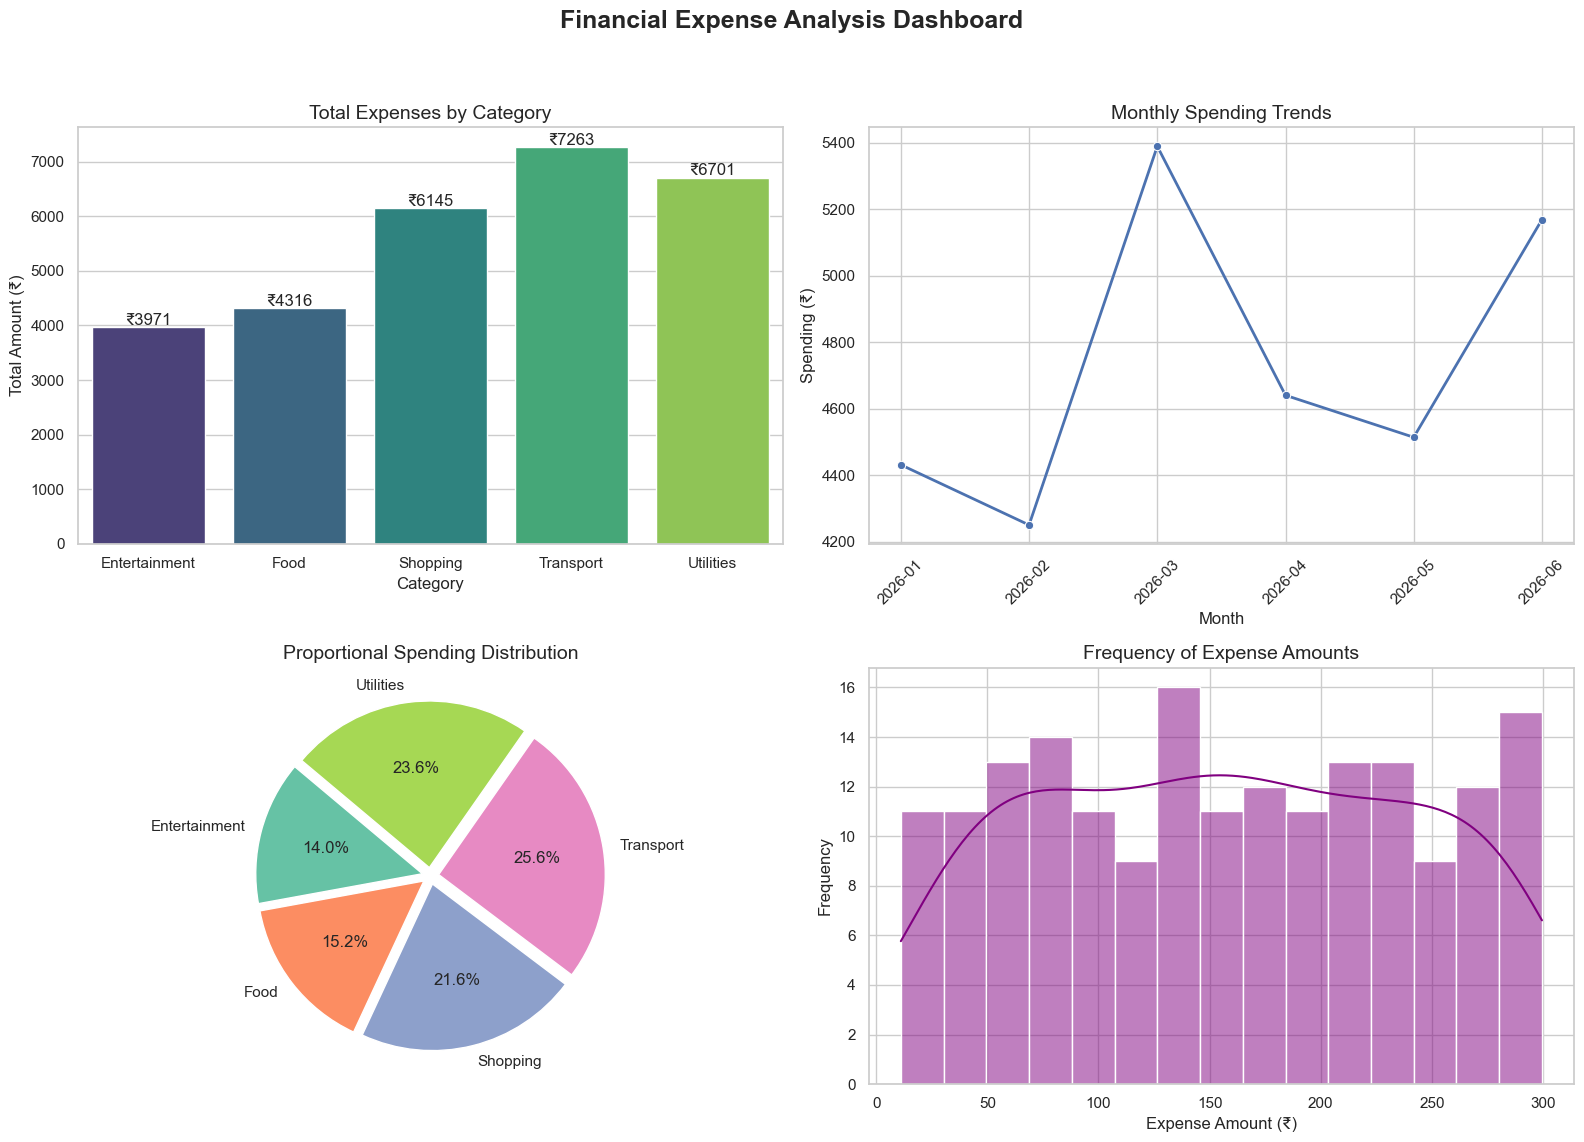

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 1. Dataset Generation 
def generate_sample_data():
    data = {
        "Date": pd.date_range(start="2026-01-01", end="2026-06-30", freq='D'),
        "Amount": np.random.uniform(5.0, 300.0, 181),
        "Category": np.random.choice(["Food", "Transport", "Utilities", "Entertainment", "Shopping"], 181),
        "Description": ["Daily expense"] * 181
    }
    df = pd.DataFrame(data)
    # Ensure realistic integer amounts for certain categories
    df["Amount"] = np.round(df["Amount"], 2)
    df.to_csv("expenses.csv", index=False)

generate_sample_data()

# 2. OOP Design & Implementation
class ExpenseTracker:
    def __init__(self, filepath):
        self.filepath = filepath
        self.df = self.load_data()

    def load_data(self):
        try:
            df = pd.read_csv(self.filepath)
            # Control Structures: Handle invalid date formats
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            df.dropna(subset=['Date', 'Amount'], inplace=True)
            # Handle invalid Amounts
            df = df[df['Amount'] > 0]
            return df
        except FileNotFoundError:
            print("File not found. Please create 'expenses.csv' first.")
            return pd.DataFrame()

    def compute_metrics(self):
        """Uses NumPy for computations."""
        if self.df.empty:
            return

        amounts = self.df['Amount'].to_numpy()
        
        # NumPy computations
        total_spending = np.sum(amounts)
        avg_spending = np.mean(amounts)
        max_spending = np.max(amounts)

        print("--- Financial Summary (NumPy) ---")
        print(f"Total Expenses : ₹{total_spending:.2f}")
        print(f"Average Expense: ₹{avg_spending:.2f}")
        print(f"Max Expense    : ₹{max_spending:.2f}")
        print("---------------------------------")

    def aggregate_data(self):
        """Uses Pandas to manipulate, filter, and aggregate new metrics."""
        # Spending Percentage by Category
        category_summary = self.df.groupby('Category')['Amount'].agg(['sum', 'count']).reset_index()
        total = category_summary['sum'].sum()
        category_summary['Spending Percentage (%)'] = (category_summary['sum'] / total) * 100

        # Monthly Average Spending
        self.df['Month'] = self.df['Date'].dt.to_period('M')
        monthly_summary = self.df.groupby('Month')['Amount'].sum().reset_index()
        monthly_summary.rename(columns={'Amount': 'Monthly Spending'}, inplace=True)

        return category_summary, monthly_summary

    def plot_visualizations(self):
        """Generates required visualizations using Matplotlib & Seaborn."""
        if self.df.empty:
            return

        cat_summary, month_summary = self.aggregate_data()

        # Set Seaborn theme for aesthetics
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Financial Expense Analysis Dashboard', fontsize=18, fontweight='bold')

        # 1. Bar Chart: Total expenses by category
        sns.barplot(ax=axes[0, 0], data=cat_summary, x='Category', y='sum', palette='viridis')
        axes[0, 0].set_title('Total Expenses by Category', fontsize=14)
        axes[0, 0].set_xlabel('Category', fontsize=12)
        axes[0, 0].set_ylabel('Total Amount (₹)', fontsize=12)
        for p in axes[0, 0].patches:
            axes[0, 0].annotate(f'₹{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

        # 2. Line Graph: Spending trends over time
        month_summary['Month'] = month_summary['Month'].astype(str)
        sns.lineplot(ax=axes[0, 1], data=month_summary, x='Month', y='Monthly Spending', marker='o', color='b', linewidth=2)
        axes[0, 1].set_title('Monthly Spending Trends', fontsize=14)
        axes[0, 1].set_xlabel('Month', fontsize=12)
        axes[0, 1].set_ylabel('Spending (₹)', fontsize=12)
        axes[0, 1].tick_params(axis='x', rotation=45)

        # 3. Pie Chart: Proportional spending distribution
        axes[1, 0].pie(cat_summary['sum'], labels=cat_summary['Category'], autopct='%1.1f%%', 
                       startangle=140, colors=sns.color_palette('Set2'), explode=[0.05]*len(cat_summary))
        axes[1, 0].set_title('Proportional Spending Distribution', fontsize=14)

        # 4. Histogram: Frequency of expense amounts
        sns.histplot(ax=axes[1, 1], data=self.df, x='Amount', bins=15, kde=True, color='purple')
        axes[1, 1].set_title('Frequency of Expense Amounts', fontsize=14)
        axes[1, 1].set_xlabel('Expense Amount (₹)', fontsize=12)
        axes[1, 1].set_ylabel('Frequency', fontsize=12)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Execution
tracker = ExpenseTracker('expenses.csv')
tracker.compute_metrics()
tracker.plot_visualizations()


# 5. Data Visualization
#    • Use Matplotlib and Seabom to create visually appealing and informative graphs
#    • Ensure all graphs have clear labels, legends, and titles.

====== FINANCIAL PERFORMANCE METRICS ======
Total Portfolio Expenses    : ₹26,000.16
Average Per Transaction     : ₹143.65
Monthly Average Spending    : ₹4,333.36



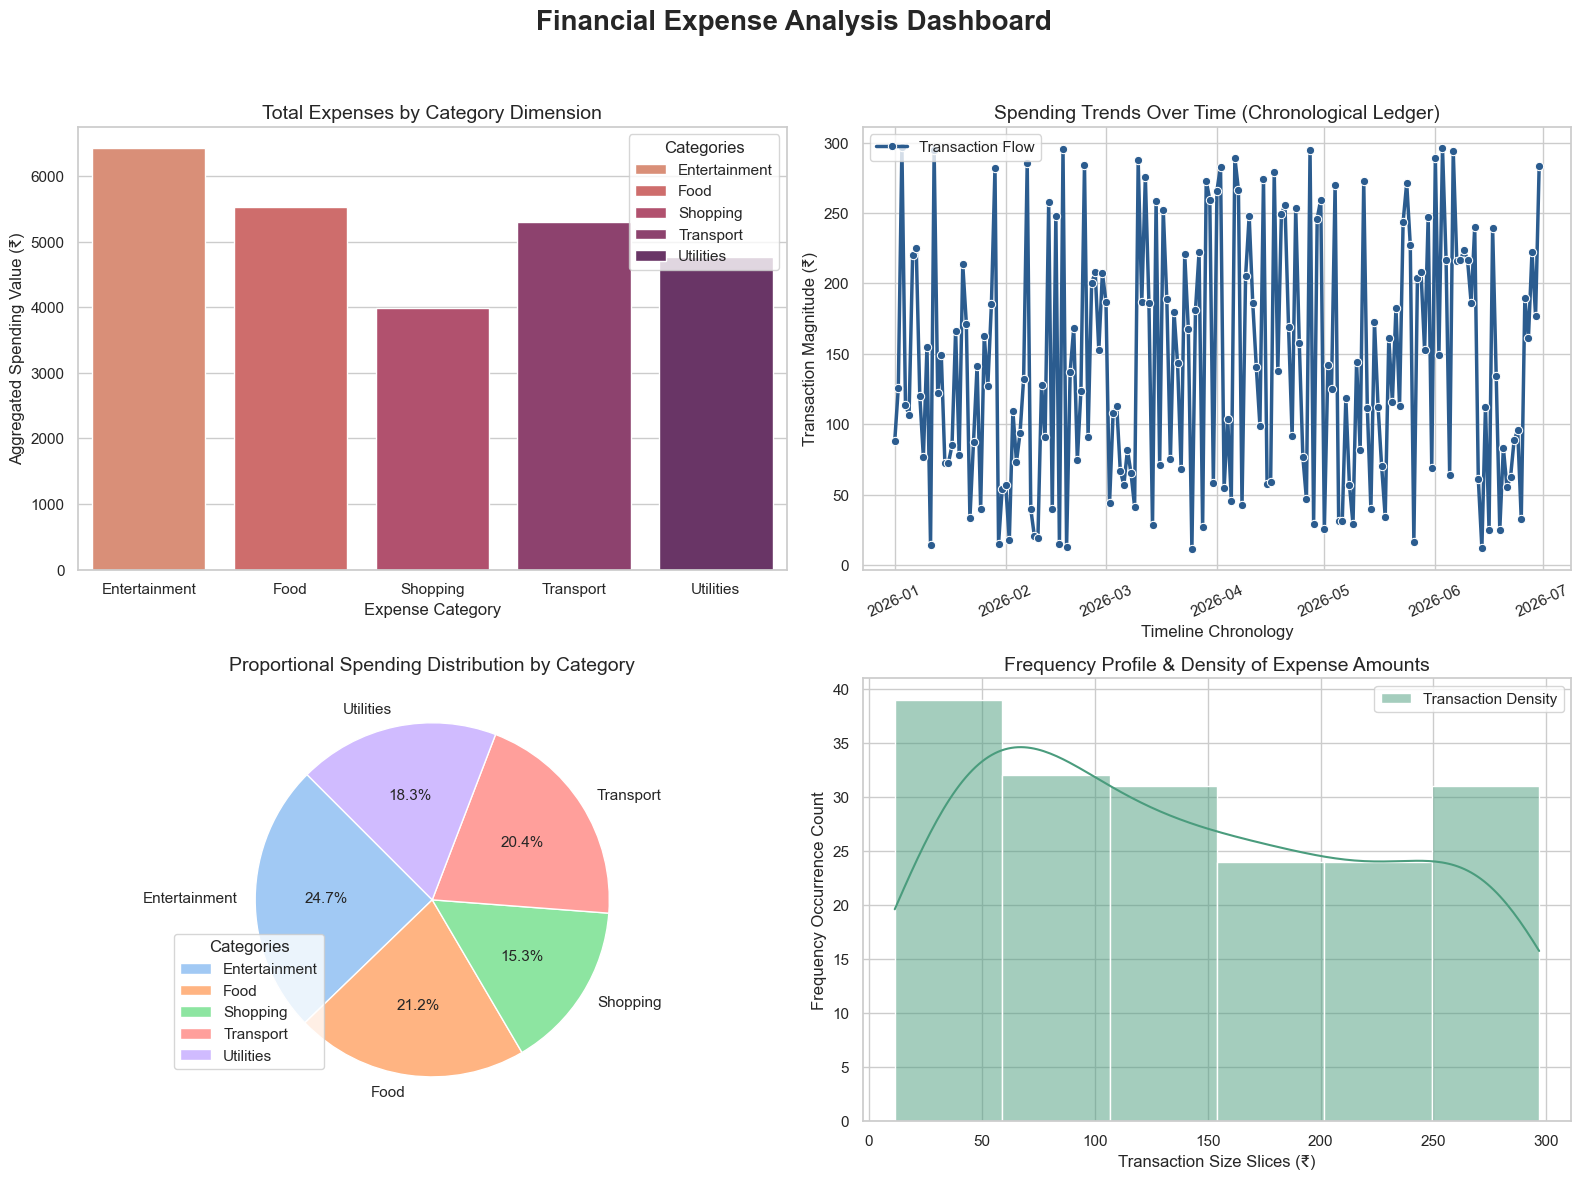

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Enforce clean visual styling globally
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

class ExpenseTracker:
    def __init__(self, filepath):
        self.filepath = filepath
        self.df = self.load_and_validate_data()

    def load_and_validate_data(self):
        """Loads dataset and uses control structures to validate format structural integrity."""
        try:
            df = pd.read_csv(self.filepath)
            valid_mask = []
            
            for index, row in df.iterrows():
                try:
                    datetime.strptime(str(row['Date']), '%Y-%m-%d')
                    if float(row['Amount']) <= 0 or pd.isna(row['Category']):
                        raise ValueError()
                    valid_mask.append(True)
                except:
                    valid_mask.append(False)
            
            df = df[valid_mask].copy()
            df['Date'] = pd.to_datetime(df['Date'])
            df['YearMonth'] = df['Date'].dt.to_period('M')
            return df
        except FileNotFoundError:
            print(f"Error: '{self.filepath}' missing.")
            return pd.DataFrame()

    def compute_metrics(self):
        """Computes summary items using pure NumPy arrays."""
        if self.df.empty: return 0
        amounts_arr = self.df['Amount'].to_numpy()
        
        total_spending = np.sum(amounts_arr)
        transaction_avg = np.mean(amounts_arr)
        monthly_average = np.mean(self.df.groupby('YearMonth')['Amount'].sum().to_numpy())
        
        print("====== FINANCIAL PERFORMANCE METRICS ======")
        print(f"Total Portfolio Expenses    : ₹{total_spending:,.2f}")
        print(f"Average Per Transaction     : ₹{transaction_avg:,.2f}")
        print(f"Monthly Average Spending    : ₹{monthly_average:,.2f}")
        print("===========================================\n")
        return total_spending

    def aggregate_category_data(self, total_spending):
        """Builds percentage allocations using combined Pandas grouping and NumPy math operations."""
        if self.df.empty: return pd.DataFrame()
        category_group = self.df.groupby('Category', as_index=False)['Amount'].sum()
        category_group['Spending Percentage'] = (category_group['Amount'].to_numpy() / total_spending) * 100
        return category_group

    def generate_financial_visualizations(self):
        """Generates a 2x2 multi-panel figure framework complete with labels, titles, and legends."""
        if self.df.empty:
            print("Visual error: Dataset unavailable.")
            return

        total_spending = self.compute_metrics()
        category_df = self.aggregate_category_data(total_spending)
        
        # Instantiate layout canvas
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Financial Expense Analysis Dashboard', fontsize=20, fontweight='bold', y=0.98)

        # -------------------------------------------------------------
        # Graph 1: Bar Chart (Total expenses by category)
        # -------------------------------------------------------------
        sns.barplot(
            ax=axes[0, 0], data=category_df, x='Category', y='Amount', 
            hue='Category', palette='flare', legend=True
        )
        axes[0, 0].set_title('Total Expenses by Category Dimension')
        axes[0, 0].set_ylabel('Aggregated Spending Value (₹)')
        axes[0, 0].set_xlabel('Expense Category')
        axes[0, 0].legend(title='Categories', loc='upper right')

        # -------------------------------------------------------------
        # Graph 2: Line Graph (Spending trends chronologically over time)
        # -------------------------------------------------------------
        timeline_df = self.df.sort_values('Date')
        sns.lineplot(
            ax=axes[0, 1], data=timeline_df, x='Date', y='Amount', 
            marker='o', color='#2b5c8f', linewidth=2.5, label='Transaction Flow'
        )
        axes[0, 1].set_title('Spending Trends Over Time (Chronological Ledger)')
        axes[0, 1].set_ylabel('Transaction Magnitude (₹)')
        axes[0, 1].set_xlabel('Timeline Chronology')
        axes[0, 1].tick_params(axis='x', rotation=25)
        axes[0, 1].legend(loc='upper left')

        # -------------------------------------------------------------
        # Graph 3: Pie Chart (Proportional distribution by category)
        # -------------------------------------------------------------
        axes[1, 0].pie(
            category_df['Amount'].to_numpy(), 
            labels=category_df['Category'].to_list(), 
            autopct='%1.1f%%', startangle=135,
            colors=sns.color_palette('pastel', len(category_df))
        )
        axes[1, 0].set_title('Proportional Spending Distribution by Category')
        # Add visual box anchor legend for pie categories
        axes[1, 0].legend(category_df['Category'].to_list(), title="Categories", loc="lower left", bbox_to_anchor=(-0.1, 0.1))

        # -------------------------------------------------------------
        # Graph 4: Histogram (Frequency distribution of transaction sizes)
        # -------------------------------------------------------------
        sns.histplot(
            ax=axes[1, 1], data=self.df, x='Amount', bins=6, 
            kde=True, color='#4a9c7d', label='Transaction Density'
        )
        axes[1, 1].set_title('Frequency Profile & Density of Expense Amounts')
        axes[1, 1].set_xlabel('Transaction Size Slices (₹)')
        axes[1, 1].set_ylabel('Frequency Occurrence Count')
        axes[1, 1].legend(loc='upper right')

        # Prevent label overlaps across multi-plot frames
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Execution Framework
if __name__ == "__main__":
    tracker = ExpenseTracker('expenses.csv')
    tracker.generate_financial_visualizations()
